# ***Procesos AR(1) estacionarios***

**Considere un proceso AR(1):**

$$
\tilde{X}_t - \phi \tilde{X}_{t-1} = Z_t \quad ; \quad \{Z_t\} \sim \text{WN}(0, \sigma_Z^2)
$$

donde:

$$
\tilde{X}_t = X_t - \mu
$$
---

**Note que**...
*Proposición*

Sea $\{Y_t\}$ una serie de tiempo estacionaria con media 0 y función de covarianza $\gamma_Y$. Si:

$$
\sum_{j=-\infty}^{\infty} |\psi_j| < \infty,
$$

entonces la serie de tiempo:

$$
X_t = \sum_{j=-\infty}^{\infty} \psi_j Y_{t-j} = \psi(B)Y_t \tag{2.2.3}
$$

es estacionaria con media 0 y función de autocovarianza:

$$
\gamma_X(h) = \sum_{j=-\infty}^{\infty} \sum_{k=-\infty}^{\infty} \psi_j \psi_k \, \gamma_Y(h + k - j) \tag{2.2.4}
$$

En el caso especial donde $\{X_t\}$ es un proceso lineal:

$$
\gamma_X(h) = \sum_{j=-\infty}^{\infty} \psi_j \psi_{j+h} \, \sigma^2 \tag{2.2.5}
$$
---

Suponga que un proceso AR(1) satisface que $|\phi| < 1$ y que $\tilde{X}_t$ no está correlacionado con $\tilde{X}_s$ para cada $s < t$.

Entonces, **probamos que este proceso es estacionario.**


Sin pérdida de generalidad, suponga que $\mu = 0$, entonces:

$$
X_t = \phi X_{t-1} + Z_t
$$

$$
X_t = \phi(\phi X_{t-2} + Z_{t-1}) + Z_t 
$$

$$
X_t = \phi^2 X_{t-2} + \phi Z_{t-1} + Z_t
$$

$$
X_t = \phi^2(\phi X_{t-3} + Z_{t-2}) + \phi Z_{t-1} + Z_t 
$$

$$
X_t = \phi^3 X_{t-3} + \phi^2 Z_{t-2} + \phi Z_{t-1} + Z_t
$$

...

En general:

$$
X_t = \phi^k X_{t-k} + \sum_{j=0}^{k-1} \phi^j Z_{t-j}
$$

Como $|\phi| < 1$, al tomar $k \to \infty$, entonces:

$$
X_t = \sum_{j=0}^{\infty} \phi^j Z_{t-j}
$$

Es decir, $X_t$ se puede expresar como un proceso lineal en términos de los errores pasados, lo que implica:

$$
X_t = \phi(B)Z_t
$$
.


Por la *Proposición* podemos concluir que el proceso
$$
X_t=\phi X_{t-1}+Z_t,\qquad |\phi|<1,\ \ \{Z_t\}\sim \text{WN}(0,\sigma_Z^2)
$$
es **estacionario**, con media cero y **función de autocovarianza** dada por

$$
\gamma_X(h) = \sum_{j=-\infty}^{\infty} \sum_{k=-\infty}^{\infty} \psi_j \psi_k \, \gamma_Y(h + k - j)
$$

**Y en el caso especial donde $\{X_t\}$ es un proceso lineal**:

$$
\gamma_X(h) = \sum_{j=-\infty}^{\infty} \psi_j \psi_{j+h} \, \sigma^2
$$


$$
\gamma_X(h) = \sum_{j=-\infty}^{\infty} \psi_j \psi_{j+h} \sigma_Z^2 = \sum_{j=0}^{\infty} \phi^j \phi^{j+h} \sigma_Z^2 = \sum_{j=0}^{\infty} \phi^{2j} \phi^h \sigma_Z^2
$$


Como $|\phi| < 1$ entonces

$$
\sum_{j=0}^{\infty} \phi^{2j} \phi^h \sigma_Z^2 \quad \text{converge a} \quad \frac{\phi^h \sigma_Z^2}{1 - \phi^2}
$$

Por lo tanto

$$
\gamma_X(h) = \frac{\phi^{|h|} \sigma_Z^2}{1 - \phi^2} \quad ; \quad h \geq 0
$$

Calculemos la función de autocorrelación del proceso AR(1)

$$
\rho_X(h) = \frac{\gamma_X(h)}{\gamma_X(0)}
$$


$$
\gamma_X(0) = \text{Var}(X_t) = \text{Var}(\phi X_{t-1} + Z_t) = \phi^2 \text{Var}(X_{t-1}) + \text{Var}(Z_t)
$$

$$
= \phi^2 \text{Var}(X_{t-1}) + \sigma_Z^2
$$

$$
\text{Var}(X_t) - \phi^2 \text{Var}(X_{t-1}) = \sigma_Z^2
$$

$$
(1 - \phi^2) \, \text{Var}(X_t) = \sigma_Z^2
$$

$$
\text{Var}(X_t) = \frac{\sigma_Z^2}{1 - \phi^2}
$$


De esta forma, se tiene

$$
\rho_X(h) = \frac{\phi^{|h|} \, \sigma_Z^2}{1 - \phi^2} - \frac{\sigma_Z^2}{1 - \phi^2} = \phi^{|h|} \quad ; \quad h \geq 0
$$


---

**Ejemplo, considere el proceso**

$$
(1 - 0.4B) X_t = Z_t \quad ; \quad \{Z_t\} \sim \text{WN}(0, \sigma_Z^2)
$$

$$
\phi = 0.4
$$

$$
\rho_1 = \phi \\
\rho_2 = \phi^2 \\
\rho_3 = \phi^3 \\
\vdots
$$


Gráfico de la FAC teórica del proceso $(1 - 0.4B) X_t = Z_t$


In [1]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "png"

# ---------- ACF teórica AR(p) con convención X_t - sum(phi_j X_{t-j}) = Z_t ----------
def acf_ar_negative(phi, m=24, M=1000):
    """
    phi: iterable (phi1,...,phi_p) con TU convención (el modelo lleva '−' delante).
    m  : rezago máximo a devolver (inclusive).
    M  : truncación para los pesos MA(∞) (entre 500-2000 suele bastar si el AR es estable).
    return: lags (0..m), rho
    """
    phi = np.asarray(phi, dtype=float)
    p = len(phi)

    # psi-weights del AR como MA(∞)
    psi = np.zeros(M+1)
    psi[0] = 1.0
    for k in range(1, M+1):
        # psi_k = sum_{j=1}^p phi_j * psi_{k-j}
        acc = 0.0
        for j in range(1, p+1):
            if k-j >= 0:
                acc += phi[j-1] * psi[k-j]
        psi[k] = acc

    # autocovarianzas (sigma^2 factor se cancela al normalizar)
    gamma = np.zeros(m+1)
    for k in range(m+1):
        # sum_{i=0}^{M-k} psi_i * psi_{i+k}
        gamma[k] = np.dot(psi[:M-k+1], psi[k:M+1])

    rho = gamma / gamma[0]
    lags = np.arange(m+1)
    return lags, rho

# ---------- Stem-plot en Plotly (líneas, no barras) ----------
def plot_acf_stem_plotly(lags, rho, title="ACF teórica (AR)", n_for_ci=None):
    xs, ys = [], []
    for k, r in zip(lags, rho):
        xs += [k, k, None]
        ys += [0, r, None]
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=xs, y=ys, mode="lines", line=dict(width=2), name="líneas"))
    fig.add_trace(go.Scatter(x=lags, y=rho, mode="markers", marker=dict(size=7), name="ρ_k"))
    fig.add_hline(y=0, line_width=1, line_dash="dot", line_color="gray")
    if n_for_ci is not None and n_for_ci > 0:
        ci = 1.96/np.sqrt(n_for_ci)
        fig.add_hrect(y0=-ci, y1=ci, line_width=0, fillcolor="lightgray",
                      opacity=0.25, annotation_text=f"±{ci:.3f}",
                      annotation_position="top left")
    fig.update_layout(template="plotly_white", width=800, height=380,
                      title=title, xaxis_title="Rezago k", yaxis_title="ρ_k")
    return fig


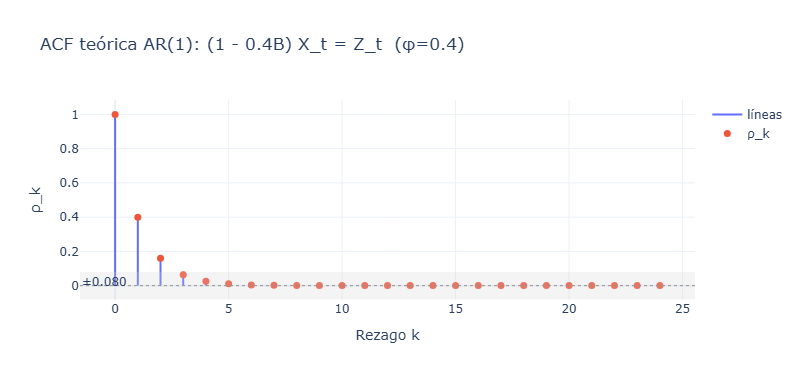

In [2]:

# Ejemplo
# AR(1) con tu notación:  X_t - φ X_{t-1} = Z_t, φ = 0.4
phi = [0.4]
lags, rho = acf_ar_negative(phi, m=24)
fig = plot_acf_stem_plotly(lags, rho,
       title="ACF teórica AR(1): (1 - 0.4B) X_t = Z_t  (φ=0.4)",
       n_for_ci=600)  # banda opcional estilo ±1.96/√N
fig.show()


In [3]:
from pizarras.plotly_pages import PlotlyPagesPublisher
publisher = PlotlyPagesPublisher(
    github_username="nuriaarroyo",
    github_repo="ecoII",
    pages_root="docs",
)

out_path, public_url, pdf_url = publisher.save_html(
    fig,
    site_subfolder="interactive",
    print_link=False,
)

# Use pdf_url in whatever text you expect to export to PDF
pdf_url

'https://nuriaarroyo.github.io/ecoII/interactive/ACF_te%C3%B3rica_AR_1_1_-_0_4B_X_t_Z_t_%CF%86_0_4.html'